In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("../data/train.csv")

df["date"] = pd.to_datetime(df["date"])

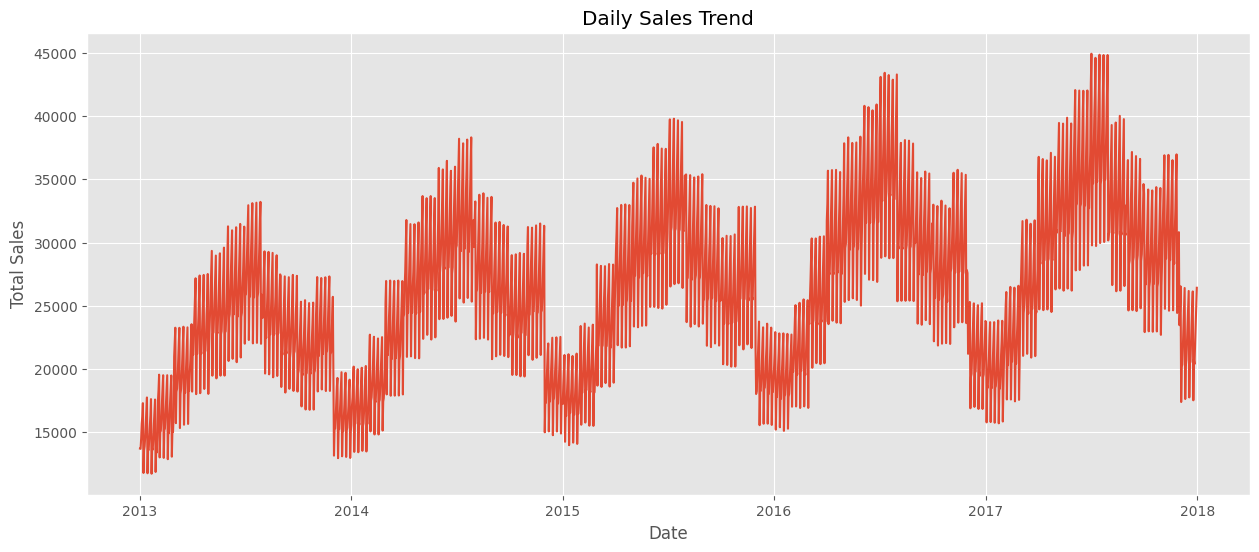

In [2]:
daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(15,6))
plt.plot(daily_sales)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

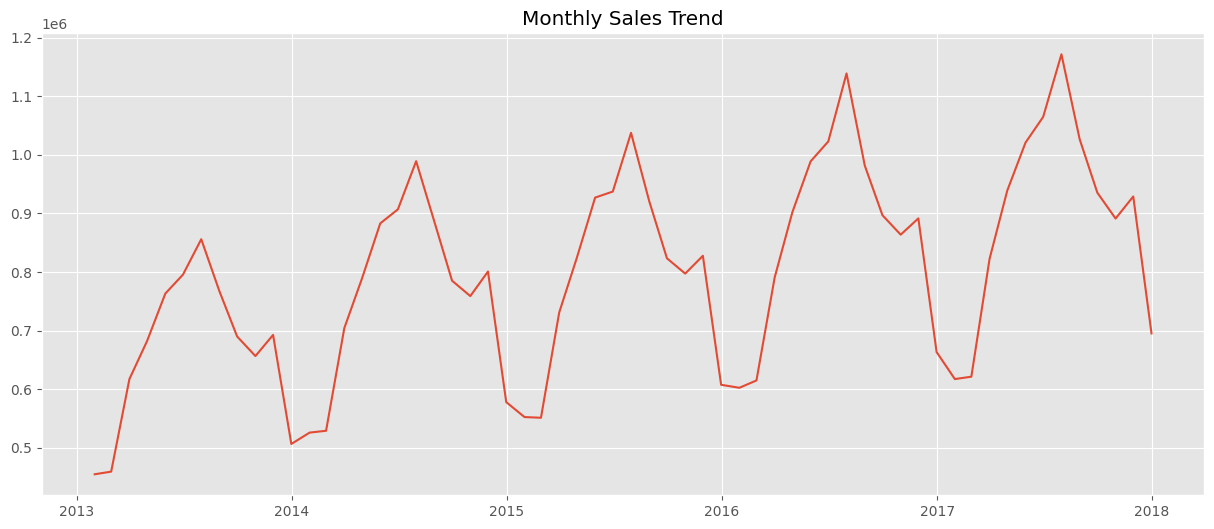

In [4]:
monthly_sales = (df.set_index("date").resample("ME")["sales"].sum())

plt.figure(figsize=(15,6))
plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")

plt.show()

In [6]:
yearly_sales = (df.set_index("date").resample("YE")["sales"].sum())

print(yearly_sales)

date
2013-12-31     7941243
2014-12-31     9135482
2015-12-31     9536887
2016-12-31    10357160
2017-12-31    10733740
Freq: YE-DEC, Name: sales, dtype: int64


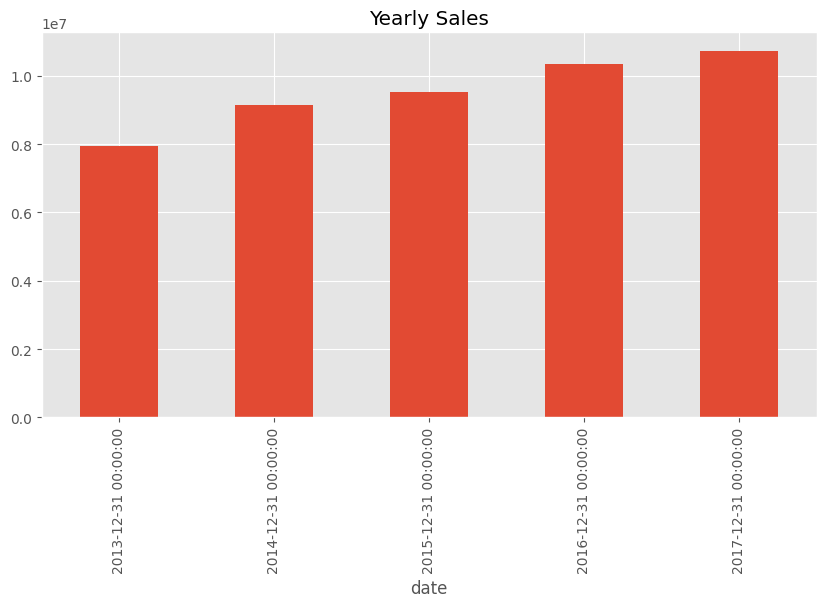

In [7]:
yearly_sales.plot(kind="bar", figsize=(10,5))

plt.title("Yearly Sales")
plt.show()

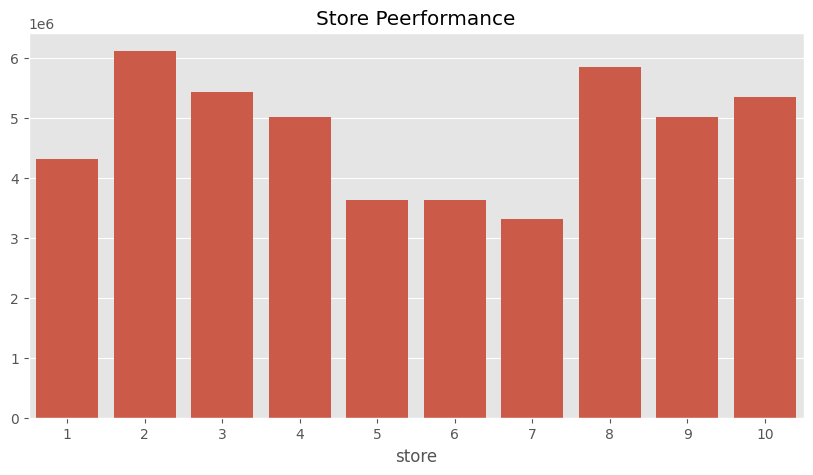

In [8]:
store_sales = (df.groupby("store")["sales"].sum().sort_values(ascending=False))

plt.figure(figsize=(10,5))

sns.barplot(x=store_sales.index, y=store_sales.values)

plt.title("Store Peerformance")

plt.show()

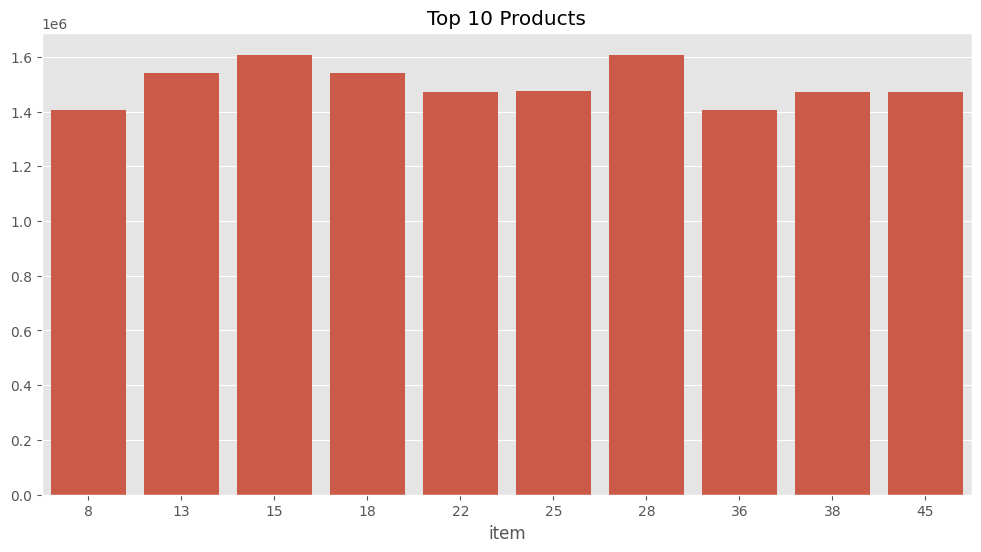

In [10]:
item_sales = (df.groupby("item")["sales"].sum().sort_values(ascending=False))

top10 = item_sales.head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top10.index, y=top10.values)

plt.title("Top 10 Products")

plt.show()

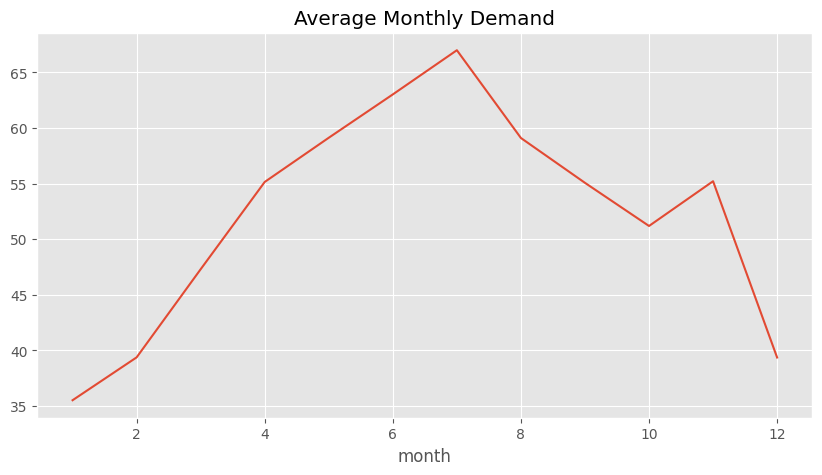

In [11]:
df["month"] = df["date"].dt.month

monthly_pattern = (
    df.groupby("month")["sales"]
    .mean()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_pattern.index,
    y=monthly_pattern.values
)

plt.title("Average Monthly Demand")

plt.show()

In [13]:
df["day_of_week"] = df["date"].dt.day_name()

dow_sales = (
    df.groupby("day_of_week")["sales"]
    .mean()
)

print(dow_sales)

day_of_week
Friday       55.157249
Monday       41.429638
Saturday     58.662697
Sunday       62.143333
Thursday     51.723218
Tuesday      48.225908
Wednesday    48.368506
Name: sales, dtype: float64


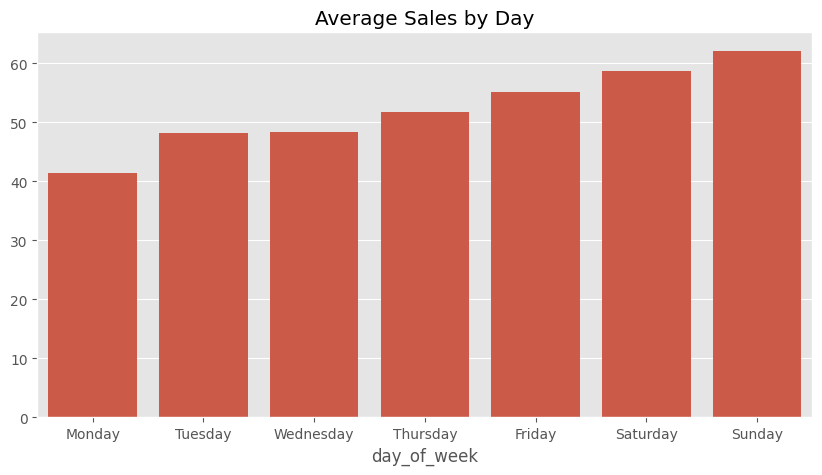

In [14]:
dow_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dow_sales = dow_sales.reindex(dow_order)

plt.figure(figsize=(10,5))

sns.barplot(
    x=dow_sales.index,
    y=dow_sales.values
)

plt.title("Average Sales by Day")

plt.show()

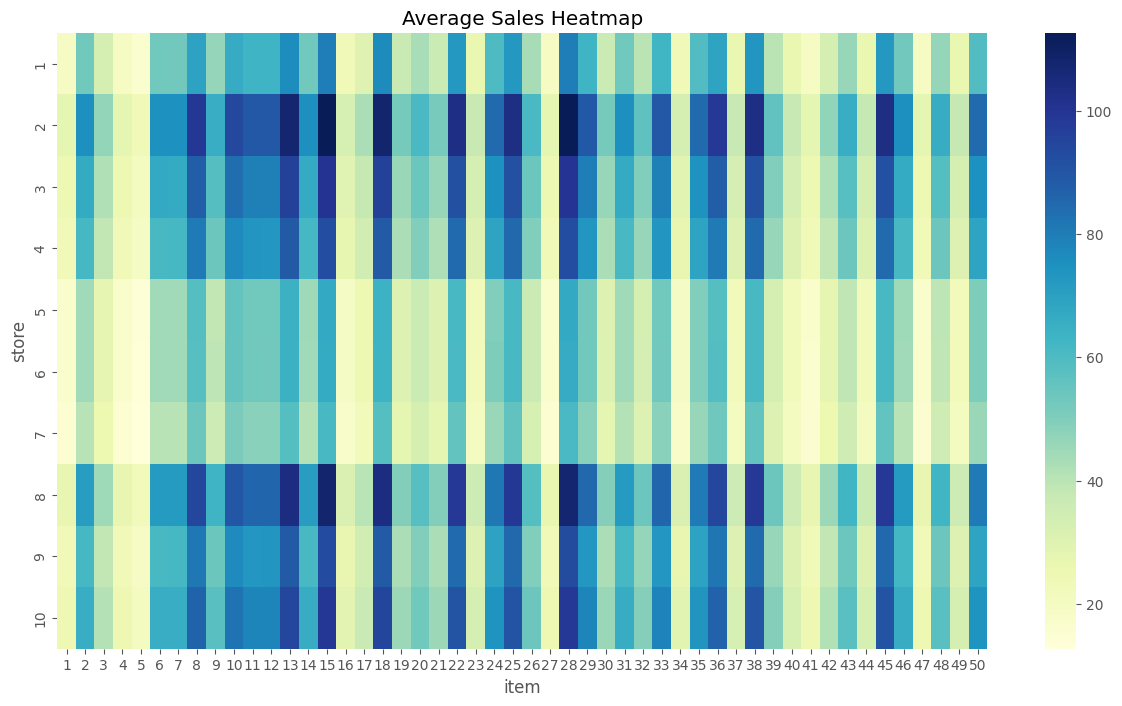

In [15]:
pivot = df.pivot_table(
    values="sales",
    index="store",
    columns="item",
    aggfunc="mean"
)

plt.figure(figsize=(15,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Average Sales Heatmap")

plt.show()